In [ ]:
from openai import OpenAI
import os
os.environ["OPENAI_API_KEY"] = "token"
import json
import tiktoken
from bs4 import BeautifulSoup
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np


In [2]:
def strip_code_fences(text: str) -> str:
    """
    Remove Markdown code fences like ```latex ... ``` from model output.
    """
    # Remove starting and ending triple backticks with optional language tag
    if text.startswith("```"):
        # split into lines, drop first and last if they're code fences
        lines = text.splitlines()
        if lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines)
    return text

In [ ]:
model = "gpt-5"
for i in range(1, 6):
    folder = f"session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"session/project_{i}_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    store = []
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output = strip_code_fences(raw_output)
            
            # human output
            human_output_folder = f"session_experiment/human_output/{i}/{rec['index']}.txt"
            os.makedirs(os.path.dirname(human_output_folder), exist_ok=True)
            
            with open(human_output_folder, "w") as f:
                f.write(rec['after_text'])
            

### Edit distance

#### generate result

In [5]:
import Levenshtein

In [8]:
for i in range(1, 6):
    folder = f"session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"session/project_{i}_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    store = []
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output = strip_code_fences(raw_output)

            lev = Levenshtein.ratio(rec['after_text'], model_output)
            
            record = {
                "index": rec["index"],
                "duration": rec['duration'],
                "levenshtein": lev,
                "label_list": rec['label_list']
            }
            store.append(record)
    output_file = f"session_experiment/levenshtein/{model}/project_{i}.jsonl"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as f:
        for record in store:
            f.write(json.dumps(record) + "\n")
            

#### plot temp

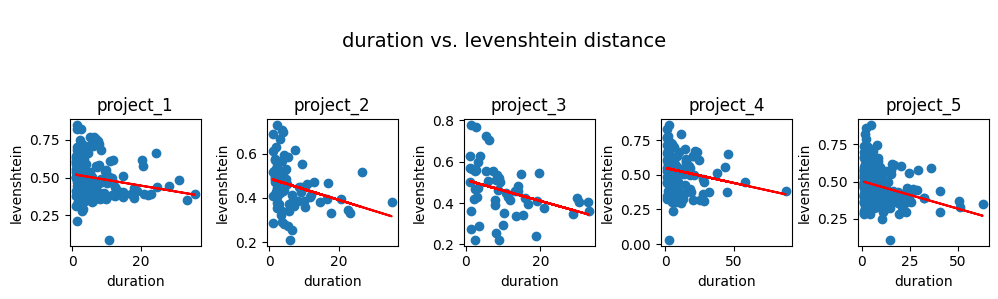

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))  # 2 rows, 3 columns
axes = axes.flatten()  # make it easier to index

for i in range(1, 6):  # 5 projects
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    m, b = np.polyfit(duration_list, lev_list, 1)
    ax = axes[i-1]
    ax.plot(duration_list, np.array(duration_list)*m + b, color="red")
    ax.scatter(duration_list, lev_list)
    ax.set_xlabel("duration")
    ax.set_ylabel("levenshtein")
    ax.set_title(f"project_{i}")

# Hide the unused subplot (the 6th one)
fig.suptitle("\nduration vs. levenshtein distance\n", fontsize=14)
plt.tight_layout()
plt.show()


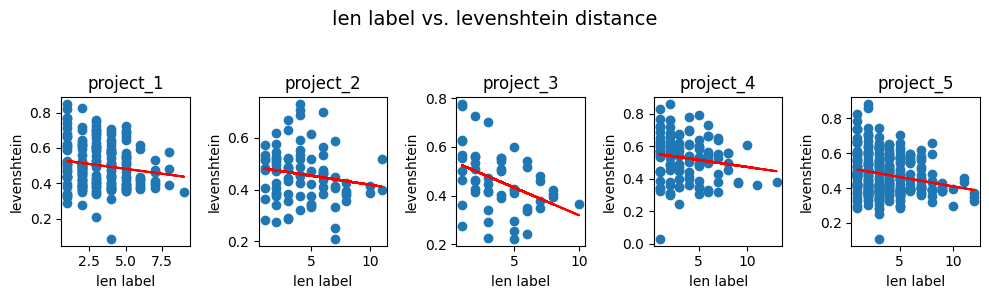

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))  # 2 rows, 3 columns
axes = axes.flatten()  # make it easier to index

for i in range(1, 6):  # 5 projects
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    lev_list = [rec['levenshtein'] for rec in data]
    label_len_list = [len(rec['label_list']) for rec in data]
    m, b = np.polyfit(label_len_list, lev_list, 1)
    ax = axes[i-1]
    ax.plot(label_len_list, np.array(label_len_list)*m + b, color="red")
    ax.scatter(label_len_list, lev_list)
    ax.set_xlabel("len label")
    ax.set_ylabel("levenshtein")
    ax.set_title(f"project_{i}")

# Hide the unused subplot (the 6th one)
fig.suptitle("len label vs. levenshtein distance\n", fontsize=14)
plt.tight_layout()
plt.show()


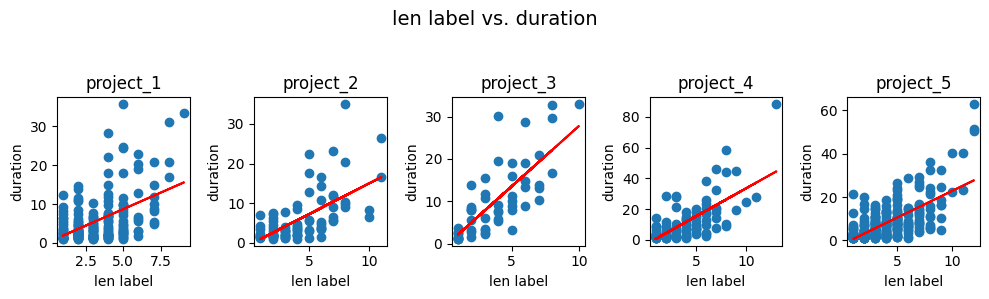

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))  # 2 rows, 3 columns
axes = axes.flatten()  # make it easier to index

for i in range(1, 6):  # 5 projects
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    duration_list = [rec['duration'] for rec in data]
    label_len_list = [len(rec['label_list']) for rec in data]
    m, b = np.polyfit(label_len_list, duration_list, 1)
    ax = axes[i-1]
    ax.plot(label_len_list, np.array(label_len_list)*m + b, color="red")
    ax.scatter(label_len_list, duration_list)
    ax.set_xlabel("len label")
    ax.set_ylabel("duration")
    ax.set_title(f"project_{i}")

# Hide the unused subplot (the 6th one)
fig.suptitle("len label vs. duration\n", fontsize=14)
plt.tight_layout()
plt.savefig("figs/count_label_in_session.pdf", bbox_inches="tight", pad_inches=0)

plt.show()


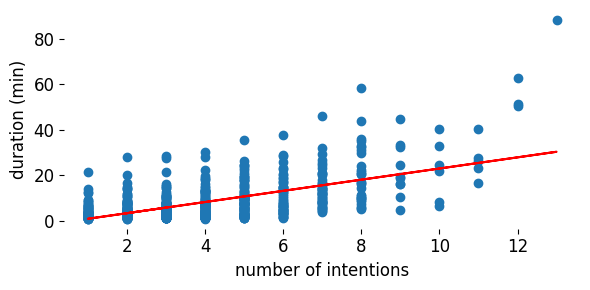

In [15]:
duration_list = []
label_len_list = []
for i in range(1, 6):  # 5 projects
    with open(f"session_experiment/levenshtein/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    duration_list += [rec['duration'] for rec in data]
    label_len_list += [len(rec['label_list']) for rec in data]
    
m, b = np.polyfit(label_len_list, duration_list, 1)
plt.figure(figsize=(6, 3))

plt.plot(label_len_list, np.array(label_len_list)*m + b, color="red")
plt.scatter(label_len_list, duration_list)
plt.xlabel("number of intentions", fontsize=12)
plt.ylabel("duration (min)", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Hide the unused subplot (the 6th one)
for spine in ["top", "right", "left", "bottom"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("figs/duration_num_intention.pdf", bbox_inches="tight", pad_inches=0)

plt.show()


#### plot official

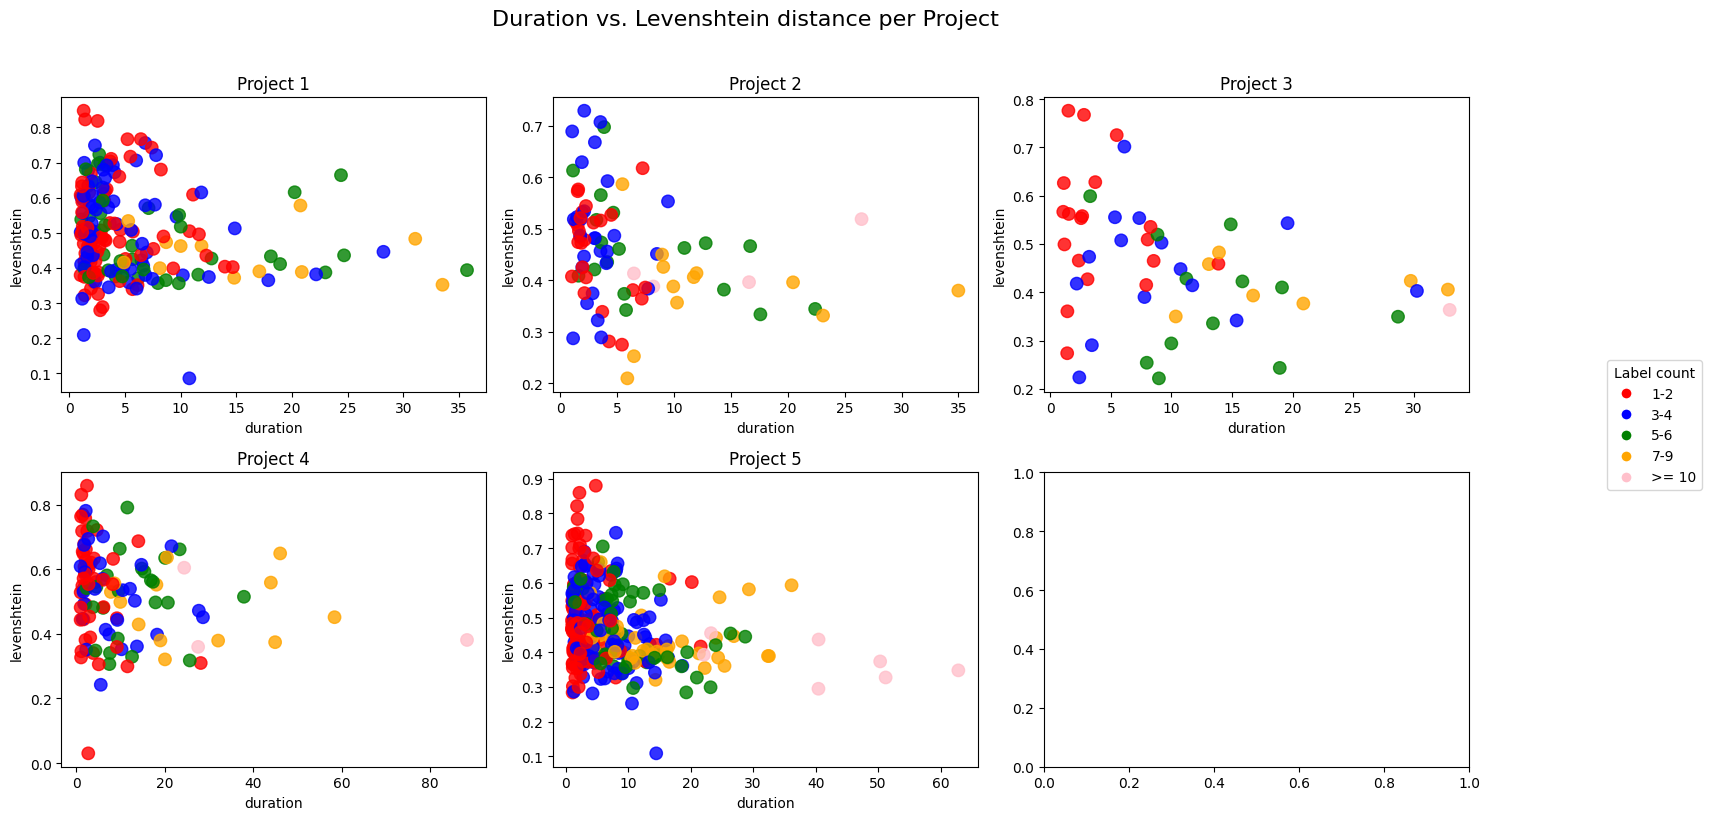

In [13]:
def get_color(length):
    if length < 3:
        return "red"
    elif length < 5:
        return "blue"
    elif length < 7:
        return "green"
    elif length < 10:
        return "orange"
    else:
        return "pink"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2x3 grid
axes = axes.flatten()  # make it iterable

for i in range(1, 6):
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    len_list = [len(rec['label_list']) for rec in data]
    point_colors = [get_color(l) for l in len_list]

    ax = axes[i-1]
    ax.scatter(duration_list, lev_list, c=point_colors, s=80, alpha=0.8)
    ax.set_title(f"Project {i}")
    ax.set_xlabel("duration")
    ax.set_ylabel("levenshtein")



# Shared legend for label counts
color_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="red", markersize=8, label="1-2"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="blue", markersize=8, label="3-4"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="green", markersize=8, label="5-6"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="orange", markersize=8, label="7-9"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="pink", markersize=8, label=">= 10"),
]
fig.legend(handles=color_handles, title="Label count",
           bbox_to_anchor=(1.07, 0.5), loc="center left")

plt.suptitle("Duration vs. Levenshtein distance per Project", fontsize=16, y=1.02)
plt.savefig("figs/session_duration_vs_levenshtein_per_project.png")

plt.tight_layout()
plt.show()

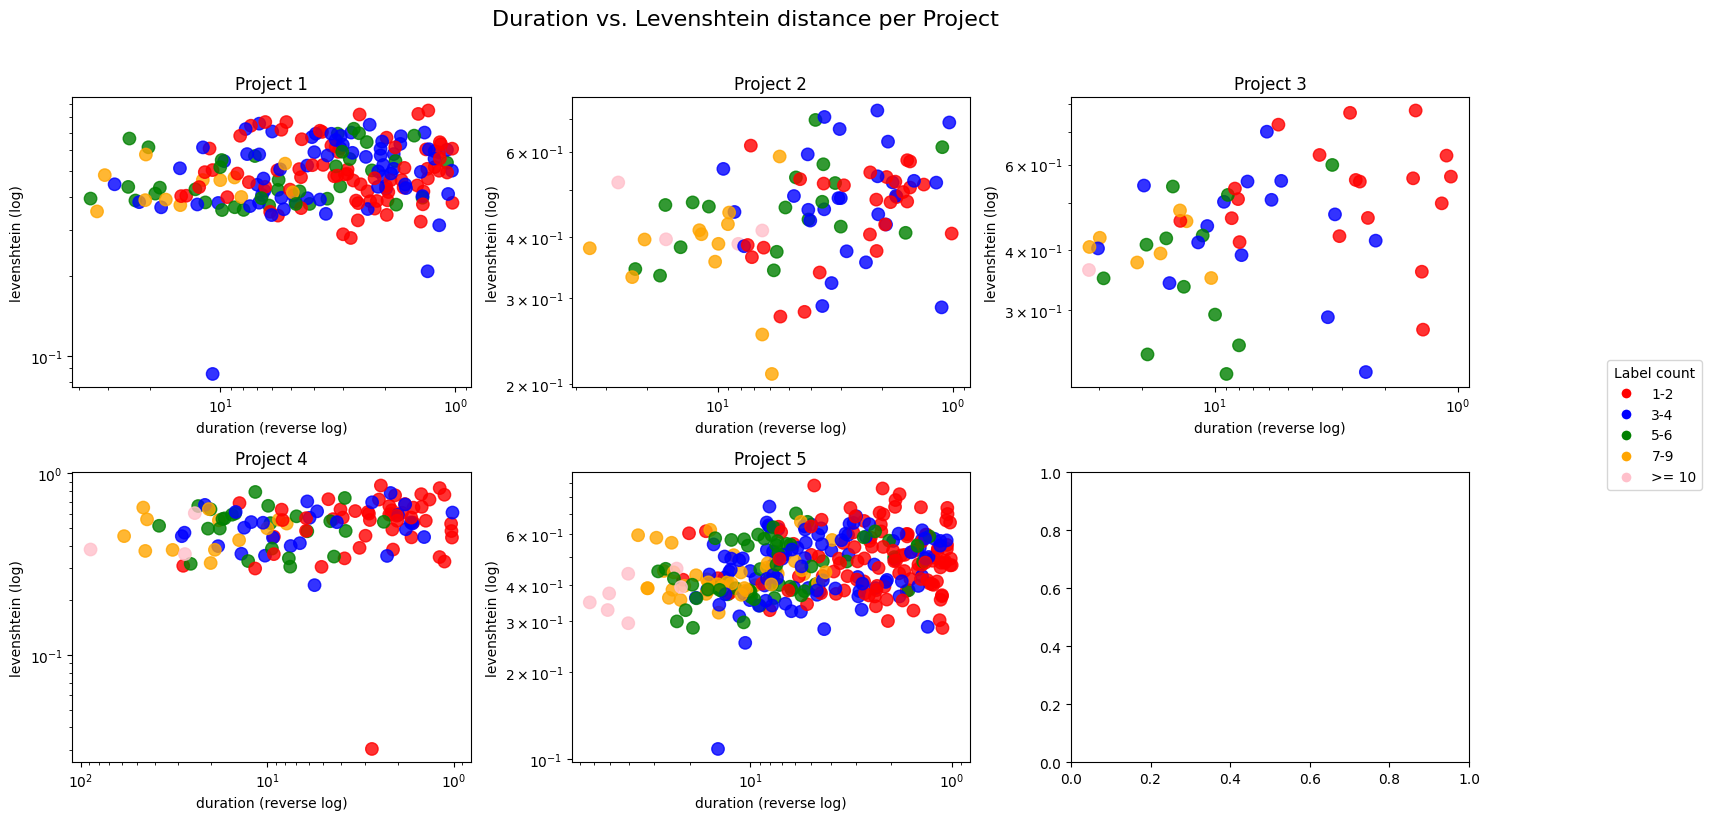

In [14]:
def get_color(length):
    if length < 3:
        return "red"
    elif length < 5:
        return "blue"
    elif length < 7:
        return "green"
    elif length < 10:
        return "orange"
    else:
        return "pink"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2x3 grid
axes = axes.flatten()  # make it iterable

for i in range(1, 6):
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    len_list = [len(rec['label_list']) for rec in data]
    point_colors = [get_color(l) for l in len_list]

    ax = axes[i-1]
    ax.scatter(duration_list, lev_list, c=point_colors, s=80, alpha=0.8)
    ax.set_title(f"Project {i}")
    ax.set_xlabel("duration (reverse log)")
    ax.set_ylabel("levenshtein (log)")

    # Apply log scales
    ax.set_yscale("log")      # log scale for y
    ax.set_xscale("log")      # log scale for x
    ax.invert_xaxis()         # reverse x-axis

# Shared legend for label counts
color_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="red", markersize=8, label="1-2"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="blue", markersize=8, label="3-4"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="green", markersize=8, label="5-6"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="orange", markersize=8, label="7-9"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="pink", markersize=8, label=">= 10"),
]
fig.legend(handles=color_handles, title="Label count",
           bbox_to_anchor=(1.07, 0.5), loc="center left")

plt.suptitle("Duration vs. Levenshtein distance per Project", fontsize=16, y=1.02)
plt.savefig("figs/session_duration_vs_levenshtein_per_project.png")

plt.tight_layout()
plt.show()


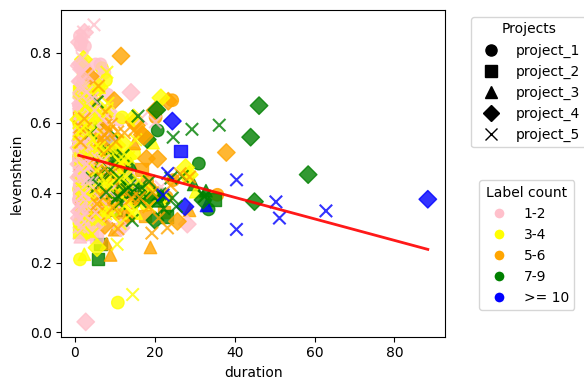

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import json

# Color buckets based on label_list length
def get_color(length):
    if length < 3:
        return "pink"
    elif length < 5:
        return "yellow"
    elif length < 7:
        return "orange"
    elif length < 10:
        return "green"
    else:
        return "blue"

# Different markers for projects
markers = ["o", "s", "^", "D", "x"]  # 5 projects

plt.figure(figsize=(6, 4))

all_durations = []
all_levs = []
for i in range(1, 6):  # 5 projects
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    len_list = [len(rec['label_list']) for rec in data]  # <-- count labels
    all_durations.extend(duration_list)
    all_levs.extend(lev_list)

    point_colors = [get_color(l) for l in len_list]

    plt.scatter(duration_list, lev_list,
                c=point_colors, marker=markers[i-1],
                s=80, alpha=0.8, label=f"project_{i}")

# --- Global regression line (all projects combined) ---
if len(all_durations) > 1:
    m, b = np.polyfit(all_durations, all_levs, 1)
    x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
    plt.plot(x_sorted, m * x_sorted + b,
             color="red", linewidth=2, alpha=0.9, label="Global trend")
    
# Legend for projects (markers)
project_handles = [plt.Line2D([0], [0], marker=m, color='k', linestyle="",
                              label=f"project_{i+1}", markersize=8)
                   for i, m in enumerate(markers)]
proj_legend = plt.legend(handles=project_handles, title="Projects",
                         bbox_to_anchor=(1.05, 1), loc="upper left")

# Legend for length categories (colors)
color_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="pink", markersize=8, label="1-2"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="yellow", markersize=8, label="3-4"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="orange", markersize=8, label="5-6"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="green", markersize=8, label="7-9"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="blue", markersize=8, label=">= 10"),
]
plt.legend(handles=color_handles, title="Label count",
           bbox_to_anchor=(1.07, 0.5), loc="upper left")

plt.gca().add_artist(proj_legend)  # ensure both legends show
# plt.xlim(1, 5)
plt.xlabel("duration")
plt.ylabel("levenshtein")
# plt.yscale("log")      # log scale for y
# plt.xscale("log")      # log scale for x
# plt.gca().invert_xaxis()
# plt.title("Duration vs. Levenshtein distance\n(Project markers × Label count colors)")
plt.tight_layout()
plt.savefig("figs/session_duration_levenshtein_aggregated_label_count_gpt5.pdf")
plt.show()


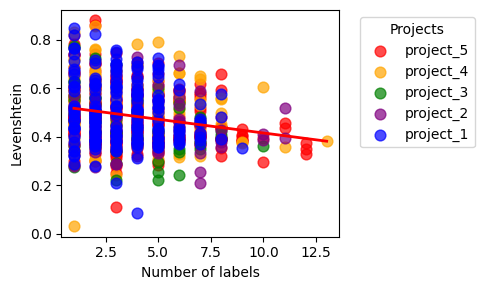

In [33]:
import matplotlib.pyplot as plt
import json

# Colors for projects
colors = ["blue", "purple", "green", "orange", "red"]

plt.figure(figsize=(5, 3))
all_len = []
all_bert = []

for i in range(5, 0, -1):
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    len_list = [len(rec['label_list']) for rec in data]
    bert_list = [rec['levenshtein'] for rec in data]
    all_len.extend(len_list)
    all_bert.extend(bert_list)

    plt.scatter(len_list, bert_list, c=colors[i-1], s=60, alpha=0.7, label=f"project_{i}")

if len(all_len) > 1:
    coeffs = np.polyfit(all_len, all_bert, 1)  # slope, intercept
    poly = np.poly1d(coeffs)
    x_vals = np.linspace(min(all_len), max(all_len), 100)
    plt.plot(x_vals, poly(x_vals), color="red", linewidth=2)

# Legend for projects (colors only)
plt.legend(title="Projects", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xlabel("Number of labels")
plt.ylabel("Levenshtein")
plt.tight_layout()
plt.savefig("figs/session_len_label_lev_gpt5.pdf")
plt.show()


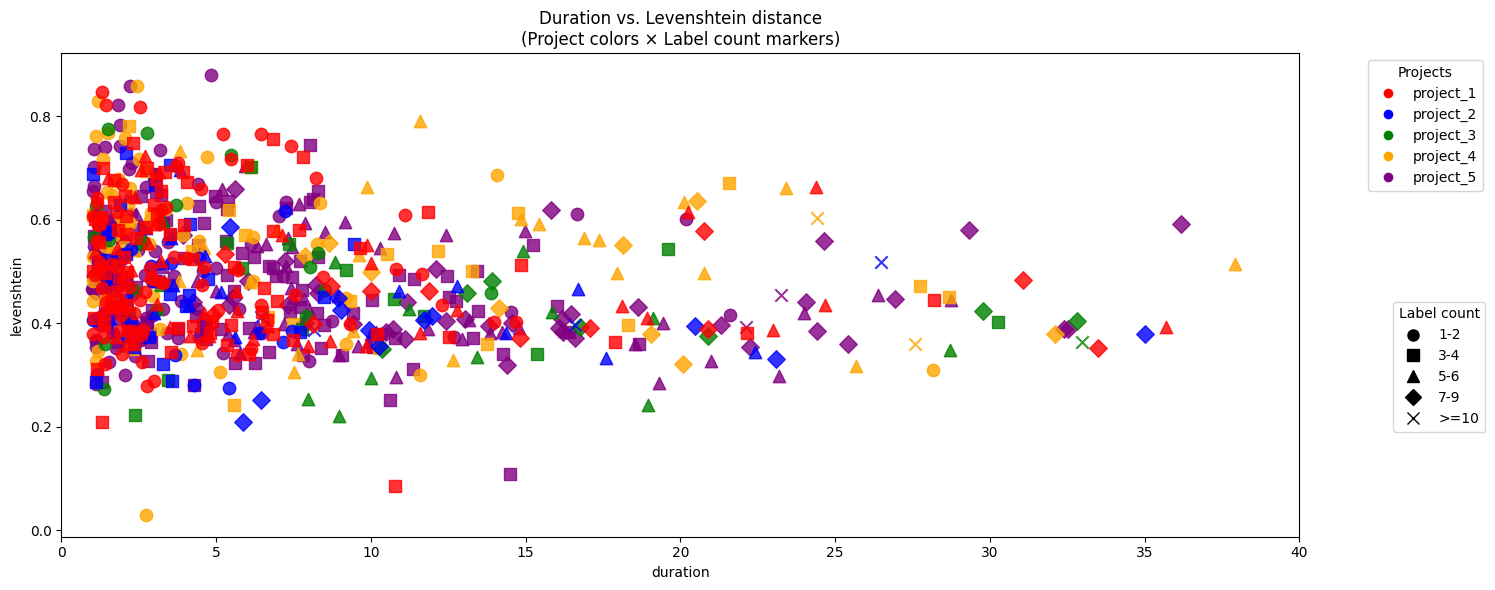

In [19]:
import matplotlib.pyplot as plt
import json

# Marker buckets based on label_list length
def get_marker(length):
    if length < 3:
        return "o"   # circle
    elif length < 5:
        return "s"   # square
    elif length < 7:
        return "^"   # triangle
    elif length < 10:
        return "D"   # diamond
    else:
        return "x"   # cross

# Colors for projects
colors = ["red", "blue", "green", "orange", "purple"]  # one per project

plt.figure(figsize=(15, 6))


for i in range(5, 0, -1):
    with open(f"session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    len_list = [len(rec['label_list']) for rec in data]

    point_markers = [get_marker(l) for l in len_list]

    for d, l, m in zip(duration_list, lev_list, point_markers):
        plt.scatter(d, l, c=colors[i-1], marker=m, s=80, alpha=0.8)

# Legend for projects (colors)
project_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                              markersize=8, label=f"project_{i+1}")
                   for i, c in enumerate(colors)]
proj_legend = plt.legend(handles=project_handles, title="Projects",
                         bbox_to_anchor=(1.05, 1), loc="upper left")

# Legend for label count (markers)
marker_handles = [
    plt.Line2D([0], [0], marker="o", color='k', linestyle="", markersize=8, label="1-2"),
    plt.Line2D([0], [0], marker="s", color='k', linestyle="", markersize=8, label="3-4"),
    plt.Line2D([0], [0], marker="^", color='k', linestyle="", markersize=8, label="5-6"),
    plt.Line2D([0], [0], marker="D", color='k', linestyle="", markersize=8, label="7-9"),
    plt.Line2D([0], [0], marker="x", color='k', linestyle="", markersize=8, label=">=10"),
]
plt.legend(handles=marker_handles, title="Label count",
           bbox_to_anchor=(1.07, 0.5), loc="upper left")

plt.gca().add_artist(proj_legend)  # ensure both legends show
plt.xlabel("duration")
plt.ylabel("levenshtein")
plt.xlim(0, 40)
plt.title("Duration vs. Levenshtein distance\n(Project colors × Label count markers)")
plt.tight_layout()
plt.savefig("figs/session_duration_levenshtein_aggregated_project.png")
plt.show()


### BERT score

#### generate result

In [5]:
from bert_score import score

/home/chi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
for i in range(1, 6):
    folder = f"session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"session/project_{i}_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    human_output_list = []
    model_output_list = []
    index_list = []
    duration_list = []
    label_list_list = []
    store = []
    
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output_list.append(strip_code_fences(raw_output))
            human_output_list.append(rec["after_text"])
            index_list.append(rec["index"])
            duration_list.append(rec["duration"])
            label_list_list.append(rec["label_list"])


    # compute BERTScore (batch mode)
    # P, R, F1 = score(cands, refs, lang="en")
    _, _, F1 = score(model_output_list, human_output_list, lang="en")

    # attach results back to records
    for index, duration, label_list, f in zip(index_list, duration_list, label_list_list, F1):
        record = {
                "index": index,
                "duration": duration,
                "bertscore_f1": f.item(),
                "label_list": label_list,
            }
        store.append(record)
    
    output_file = f"session_experiment/bertscore_f1/{model}/project_{i}.jsonl"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as f:
        for record in store:
            f.write(json.dumps(record) + "\n")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/chi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/chi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['robe

#### plot

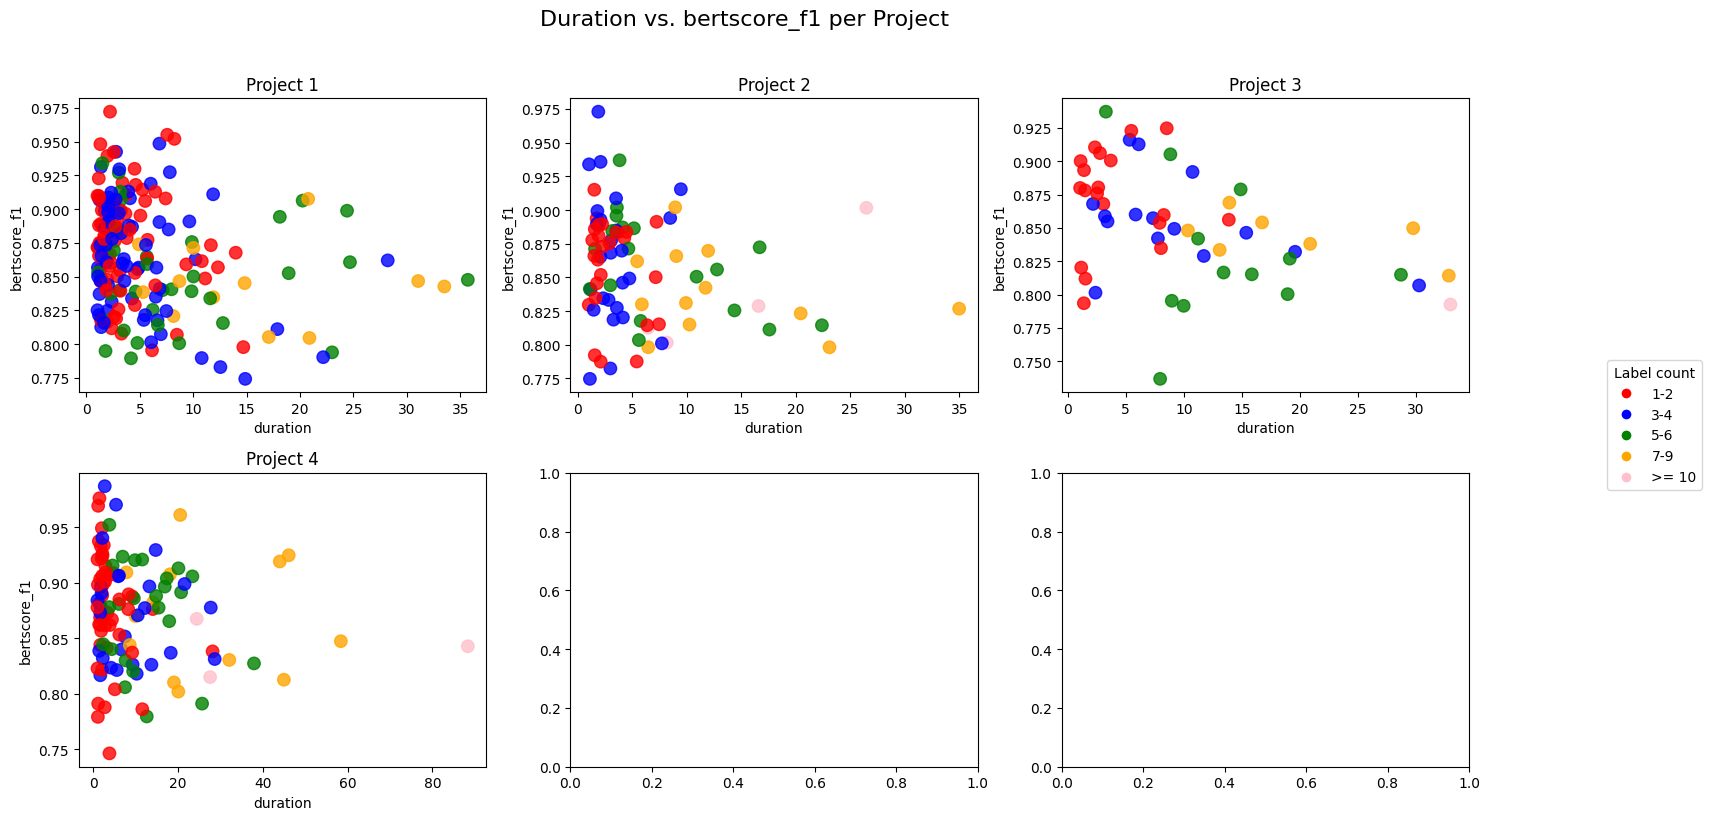

In [7]:
def get_color(length):
    if length < 3:
        return "red"
    elif length < 5:
        return "blue"
    elif length < 7:
        return "green"
    elif length < 10:
        return "orange"
    else:
        return "pink"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2x3 grid
axes = axes.flatten()  # make it iterable

for i in range(1, 5):
    with open(f"session_experiment/bertscore_f1/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    bert_list = [rec['bertscore_f1'] for rec in data]
    len_list = [len(rec['label_list']) for rec in data]
    point_colors = [get_color(l) for l in len_list]

    ax = axes[i-1]
    ax.scatter(duration_list, bert_list, c=point_colors, s=80, alpha=0.8)
    ax.set_title(f"Project {i}")
    ax.set_xlabel("duration")
    ax.set_ylabel("bertscore_f1")



# Shared legend for label counts
color_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="red", markersize=8, label="1-2"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="blue", markersize=8, label="3-4"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="green", markersize=8, label="5-6"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="orange", markersize=8, label="7-9"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="pink", markersize=8, label=">= 10"),
]
fig.legend(handles=color_handles, title="Label count",
           bbox_to_anchor=(1.07, 0.5), loc="center left")

plt.suptitle("Duration vs. bertscore_f1 per Project", fontsize=16, y=1.02)
plt.savefig("figs/session_duration_vs_bertscore_f1_per_project.png")

plt.tight_layout()
plt.show()

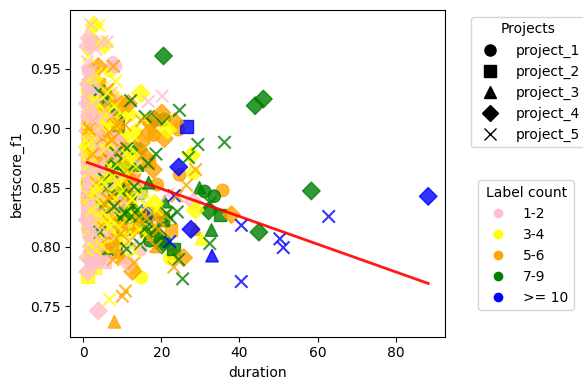

In [14]:

# Color buckets based on label_list length
def get_color(length):
    if length < 3:
        return "pink"
    elif length < 5:
        return "yellow"
    elif length < 7:
        return "orange"
    elif length < 10:
        return "green"
    else:
        return "blue"

# Different markers for projects
markers = ["o", "s", "^", "D", "x"]  # 5 projects

plt.figure(figsize=(6, 4))

all_durations = []
all_levs = []
for i in range(1, 6):  # 5 projects
    with open(f"session_experiment/bertscore_f1/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['bertscore_f1'] for rec in data]
    len_list = [len(rec['label_list']) for rec in data]  # <-- count labels
    all_durations.extend(duration_list)
    all_levs.extend(lev_list)
    
    point_colors = [get_color(l) for l in len_list]

    plt.scatter(duration_list, lev_list,
                c=point_colors, marker=markers[i-1],
                s=80, alpha=0.8, label=f"project_{i}")

# --- Global regression line (all projects combined) ---
if len(all_durations) > 1:
    m, b = np.polyfit(all_durations, all_levs, 1)
    x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
    plt.plot(x_sorted, m * x_sorted + b,
             color="red", linewidth=2, alpha=0.9, label="Global trend")
    
# Legend for projects (markers)
project_handles = [plt.Line2D([0], [0], marker=m, color='k', linestyle="",
                              label=f"project_{i+1}", markersize=8)
                   for i, m in enumerate(markers)]
proj_legend = plt.legend(handles=project_handles, title="Projects",
                         bbox_to_anchor=(1.05, 1), loc="upper left")

# Legend for length categories (colors)
color_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="pink", markersize=8, label="1-2"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="yellow", markersize=8, label="3-4"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="orange", markersize=8, label="5-6"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="green", markersize=8, label="7-9"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor="blue", markersize=8, label=">= 10"),
]
plt.legend(handles=color_handles, title="Label count",
           bbox_to_anchor=(1.07, 0.5), loc="upper left")

plt.gca().add_artist(proj_legend)  # ensure both legends show
# plt.xlim(1, 5)
plt.xlabel("duration")
plt.ylabel("bertscore_f1")
# plt.title("Duration vs. BERTScore F1\n(Project markers × Label count colors)")
plt.tight_layout()
plt.savefig("figs/session_duration_bertscore_f1_aggregated_label_count_gpt5.pdf")
plt.show()


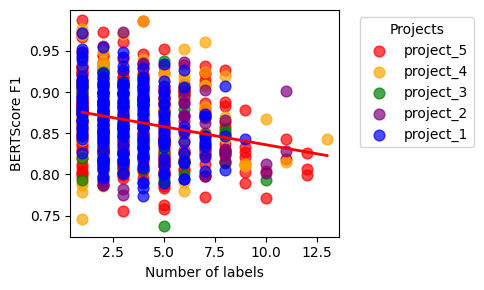

In [35]:
import matplotlib.pyplot as plt
import json

# Colors for projects
colors = ["blue", "purple", "green", "orange", "red"]

plt.figure(figsize=(5, 3))
all_len = []
all_bert = []

for i in range(5, 0, -1):
    with open(f"session_experiment/bertscore_f1/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    len_list = [len(rec['label_list']) for rec in data]
    bert_list = [rec['bertscore_f1'] for rec in data]
    all_len.extend(len_list)
    all_bert.extend(bert_list)

    plt.scatter(len_list, bert_list, c=colors[i-1], s=60, alpha=0.7, label=f"project_{i}")

if len(all_len) > 1:
    coeffs = np.polyfit(all_len, all_bert, 1)  # slope, intercept
    poly = np.poly1d(coeffs)
    x_vals = np.linspace(min(all_len), max(all_len), 100)
    plt.plot(x_vals, poly(x_vals), color="red", linewidth=2)

# Legend for projects (colors only)
plt.legend(title="Projects", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xlabel("Number of labels")
plt.ylabel("BERTScore F1")
plt.tight_layout()
plt.savefig("figs/session_len_label_bertscore_gpt5.pdf")

plt.show()
